In [2]:
import pandas as pd

rtp1 = pd.read_csv("Rtp_1.csv")
rtp2 = pd.read_csv("RTP_2.csv")

# make columns consistent
rtp1.columns = rtp1.columns.str.strip()
rtp2.columns = rtp2.columns.str.strip()

# stack
rtp = pd.concat([rtp1, rtp2], ignore_index=True)

# (optional but safe) remove exact duplicate rows
rtp = rtp.drop_duplicates()

# save merged RTP
rtp.to_csv("RTP.csv", index=False)

print("✅ Saved merged RTP file: RTP.csv | rows:", len(rtp))

✅ Saved merged RTP file: RTP.csv | rows: 20721


In [3]:
cities = {
    "Bend": "bend.csv",
    "Oakridge": "Oakridge.csv",
    "Wilmington": "Wilmington.csv",
    "RTP": "RTP.csv"   # merged file from Cell 1
}

In [4]:
summary = []

for city_name, file_name in cities.items():
    
    raw = pd.read_csv(file_name)
    before = len(raw)
    
    df = raw.copy()
    df["hr"] = pd.to_datetime(df["hr"], errors="coerce")
    df = df.dropna(subset=["hr"])
    df = df.sort_values("hr")
    df = df.drop_duplicates(subset=["hr"], keep="first")
    
    after = len(df)
    
    summary.append({
        "City": city_name,
        "Hourly observation before cleaning": before,
        "Hourly observation after cleaning": after
    })

summary_df = pd.DataFrame(summary)
summary_df

/var/folders/hg/ltbkwjt559z64dywksz2sxv80000gn/T/ipykernel_50640/3644225908.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["hr"] = pd.to_datetime(df["hr"], errors="coerce")
/var/folders/hg/ltbkwjt559z64dywksz2sxv80000gn/T/ipykernel_50640/3644225908.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["hr"] = pd.to_datetime(df["hr"], errors="coerce")
/var/folders/hg/ltbkwjt559z64dywksz2sxv80000gn/T/ipykernel_50640/3644225908.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["hr"] = pd.to_datetime(df["hr"], errors="coerce")
/var/folders/hg/ltbkwjt559z64dywksz2s

,City,Hourly observation before cleaning,Hourly observation after cleaning
0,Bend,15822,1758
1,Oakridge,16785,1865
2,Wilmington,45640,5705
3,RTP,20721,2350


In [52]:
import pandas as pd

# Load BEFORE-merge files (your cities)
# NOTE: RTP must be merged from RTP_1.csv + RTP_2.csv (prof asked)
files = {
    "Bend": "bend.csv",
    "Oakridge": "Oakridge.csv",
    "Wilmington": "Wilmington.csv",
}

dfs = []

for city, file in files.items():
    df = pd.read_csv(file)
    df["City"] = city
    dfs.append(df)

# RTP1 + RTP2 -> RTP (before-merge)
rtp1 = pd.read_csv("Rtp_1.csv")
rtp2 = pd.read_csv("RTP_2.csv")

rtp = pd.concat([rtp1, rtp2], ignore_index=True)
rtp["City"] = "RTP"
dfs.append(rtp)

# Combine into one dataframe
data = pd.concat(dfs, ignore_index=True)

print("Combined dataset shape:", data.shape)
print("Columns:", data.columns)

Combined dataset shape: (98968, 14)
Columns: Index(['Unnamed: 0', 'hr', 'city', 'id', 'RH', 'PA', 'ref', 'monitortype',
       'State', 'week', 'adj', 'adjtype', 'wholdtype', 'City'],
      dtype='object')


In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt
# ---------- RAW (before cleaning) ----------
raw_files = {
    "Bend": "bend.csv",
    "Oakridge": "Oakridge.csv",
    "Wilmington": "Wilmington.csv",
    "RTP": "RTP.csv"   # merged RTP1 + RTP2 file
}

# ---------- CLEANED (after cleaning) ----------
# Auto-pick cleaned file from cleaned_results folder
cleaned_dir = "cleaned_results"
cleaned_list = os.listdir(cleaned_dir)

def find_cleaned_file(city_key: str):
    key = city_key.lower()
    matches = [f for f in cleaned_list if key in f.lower() and f.lower().endswith(".csv")]
    if not matches:
        raise FileNotFoundError(f"No cleaned file found for '{city_key}' in {cleaned_dir}. Files: {cleaned_list}")
    # prefer files containing 'cleaned' if multiple
    matches_sorted = sorted(matches, key=lambda x: ("cleaned" not in x.lower(), len(x)))
    return os.path.join(cleaned_dir, matches_sorted[0])

clean_files = {city: find_cleaned_file(city) for city in raw_files.keys()}


raw = {city: pd.read_csv(path) for city, path in raw_files.items()}
clean = {city: pd.read_csv(path) for city, path in clean_files.items()}


In [16]:
summary_rows = []
for city in raw_files.keys():
    before = len(raw[city])

    
    after = len(clean[city])

    summary_rows.append({
        "City": city,
        "Hourly observation before cleaning": before,
        "Hourly observation after cleaning": after
    })

summary_df = pd.DataFrame(summary_rows)
# 🔹 Make index start from 1
summary_df.index = summary_df.index + 1

summary_df

summary_df.style.format({
    "Hourly observation before cleaning": "{:,}",
    "Hourly observation after cleaning": "{:,}"
})

,City,Hourly observation before cleaning,Hourly observation after cleaning
1,Bend,"15,822","1,758"
2,Oakridge,"16,785","1,865"
3,Wilmington,"45,640","5,705"
4,RTP,"20,721","1,921"


In [15]:
# ---------- SUMMARY ----------
summary = []
for city in raw_files.keys():
    before = len(raw[city])
    after = len(clean[city])

    summary.append({
        "City": city,
        "Hourly observation before cleaning": before,
        "Hourly observation after cleaning": after,
        "Reduction factor (Before/After)": round(before / after, 2) if after else None
    })

summary_df = pd.DataFrame(summary)
summary_df

# 🔹 Make index start from 1
summary_df.index = summary_df.index + 1

summary_df
summary_df.style.format({
    "Hourly observation before cleaning": "{:,}",
    "Hourly observation after cleaning": "{:,}"
})

,City,Hourly observation before cleaning,Hourly observation after cleaning,Reduction factor (Before/After)
1,Bend,"15,822","1,758",9.000000
2,Oakridge,"16,785","1,865",9.000000
3,Wilmington,"45,640","5,705",8.000000
4,RTP,"20,721","1,921",10.790000


In [20]:
import numpy as np
import pandas as pd

meteo_cols = ["temperature_2m", "windspeed_10m", "winddirection_10m"]

missing_summary = []

for city, df in clean.items():
    cols = [c for c in meteo_cols if c in df.columns]

    if not cols:
        missing = np.nan
    else:
        missing = df[cols].isna().any(axis=1).sum()

    missing_summary.append({
        "City": city,
        "Missing predictor observations": missing
    })

missing_df = pd.DataFrame(missing_summary).sort_values(
    "Missing predictor observations",
    ascending=False
)

# start index from 1
missing_df.index = missing_df.index + 1

missing_df


,City,Missing predictor observations
1,Bend,NaN
2,Oakridge,NaN
3,Wilmington,NaN
4,RTP,NaN


In [21]:
for _, row in missing_df.iterrows():
    city = row["City"]
    
    if pd.notna(row["Missing predictor observations"]):
        miss = int(row["Missing predictor observations"])
        print(f"• {city}: {miss:,} missing predictor observation(s)")
    else:
        print(f"• {city}: NA (meteorological columns not found)")

• Bend: NA (meteorological columns not found)
• Oakridge: NA (meteorological columns not found)
• Wilmington: NA (meteorological columns not found)
• RTP: NA (meteorological columns not found)


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

files = {
    "Bend": "bend.csv",
    "Oakridge": "Oakridge.csv",
    "Wilmington": "Wilmington.csv",
    "RTP": "RTP.csv"   # merged RTP1 + RTP2
}

dfs = []

for city, f in files.items():
    df = pd.read_csv(f)
    df["City"] = city
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

# Normalize column names
data.columns = data.columns.str.strip().str.lower()

# Make numeric
data["ref"] = pd.to_numeric(data["ref"], errors="coerce")
data["pa"] = pd.to_numeric(data["pa"], errors="coerce")

data.head()


,unnamed: 0,hr,city,id,rh,pa,ref,monitortype,state,week,adj,adjtype,wholdtype,city
0,2230,8/17/20 0:00,Bend_S,Bend,57.100000,18.759333,10.1,not_specified,NaN,33.0,10.714778,C,LOBD,Bend
1,2240,8/17/20 1:00,Bend_S,Bend,58.066667,18.463000,9.9,not_specified,NaN,33.0,10.602843,C,LOBD,Bend
2,2250,8/17/20 2:00,Bend_S,Bend,58.866667,15.730667,8.7,not_specified,NaN,33.0,9.575178,C,LOBD,Bend
3,2260,8/17/20 3:00,Bend_S,Bend,55.700000,15.039833,8.4,not_specified,NaN,33.0,9.316614,C,LOBD,Bend
4,2270,8/17/20 4:00,Bend_S,Bend,55.500000,15.520167,8.7,not_specified,NaN,33.0,9.496338,C,LOBD,Bend


In [55]:
import pandas as pd

# ✅ Your actual files that exist in the folder
files = {
    "Bend": "bend.csv",
    "Oakridge": "Oakridge.csv",
    "Wilmington": "Wilmington.csv",
    "RTP": "RTP.csv"   # already merged RTP1 + RTP2
}

dfs = []
for city, path in files.items():
    df = pd.read_csv(path)

    # Normalize City column (if needed)
    if "City" not in df.columns and "city" in df.columns:
        df = df.rename(columns={"city": "City"})
    if "City" not in df.columns:
        df["City"] = city

    # Force consistent labels
    df["City"] = city
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

# Make sure key columns are numeric if they exist
for col in ["ref", "pa", "adj", "rh", "temperature_2m", "windspeed_10m", "winddirection_10m"]:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors="coerce")

print("Columns:", list(data.columns))
print("Rows:", len(data))
print("Cities:", data["City"].unique())

data.head()

Columns: ['Unnamed: 0', 'hr', 'City', 'id', 'RH', 'PA', 'ref', 'monitortype', 'State', 'week', 'adj', 'adjtype', 'wholdtype']
Rows: 98968
Cities: ['Bend' 'Oakridge' 'Wilmington' 'RTP']


,Unnamed: 0,hr,City,id,RH,PA,ref,monitortype,State,week,adj,adjtype,wholdtype
0,2230,8/17/20 0:00,Bend,Bend,57.100000,18.759333,10.1,not_specified,NaN,33.0,10.714778,C,LOBD
1,2240,8/17/20 1:00,Bend,Bend,58.066667,18.463000,9.9,not_specified,NaN,33.0,10.602843,C,LOBD
2,2250,8/17/20 2:00,Bend,Bend,58.866667,15.730667,8.7,not_specified,NaN,33.0,9.575178,C,LOBD
3,2260,8/17/20 3:00,Bend,Bend,55.700000,15.039833,8.4,not_specified,NaN,33.0,9.316614,C,LOBD
4,2270,8/17/20 4:00,Bend,Bend,55.500000,15.520167,8.7,not_specified,NaN,33.0,9.496338,C,LOBD


/var/folders/hg/ltbkwjt559z64dywksz2sxv80000gn/T/ipykernel_50640/3755288293.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/hg/ltbkwjt559z64dywksz2sxv80000gn/T/ipykernel_50640/3755288293.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


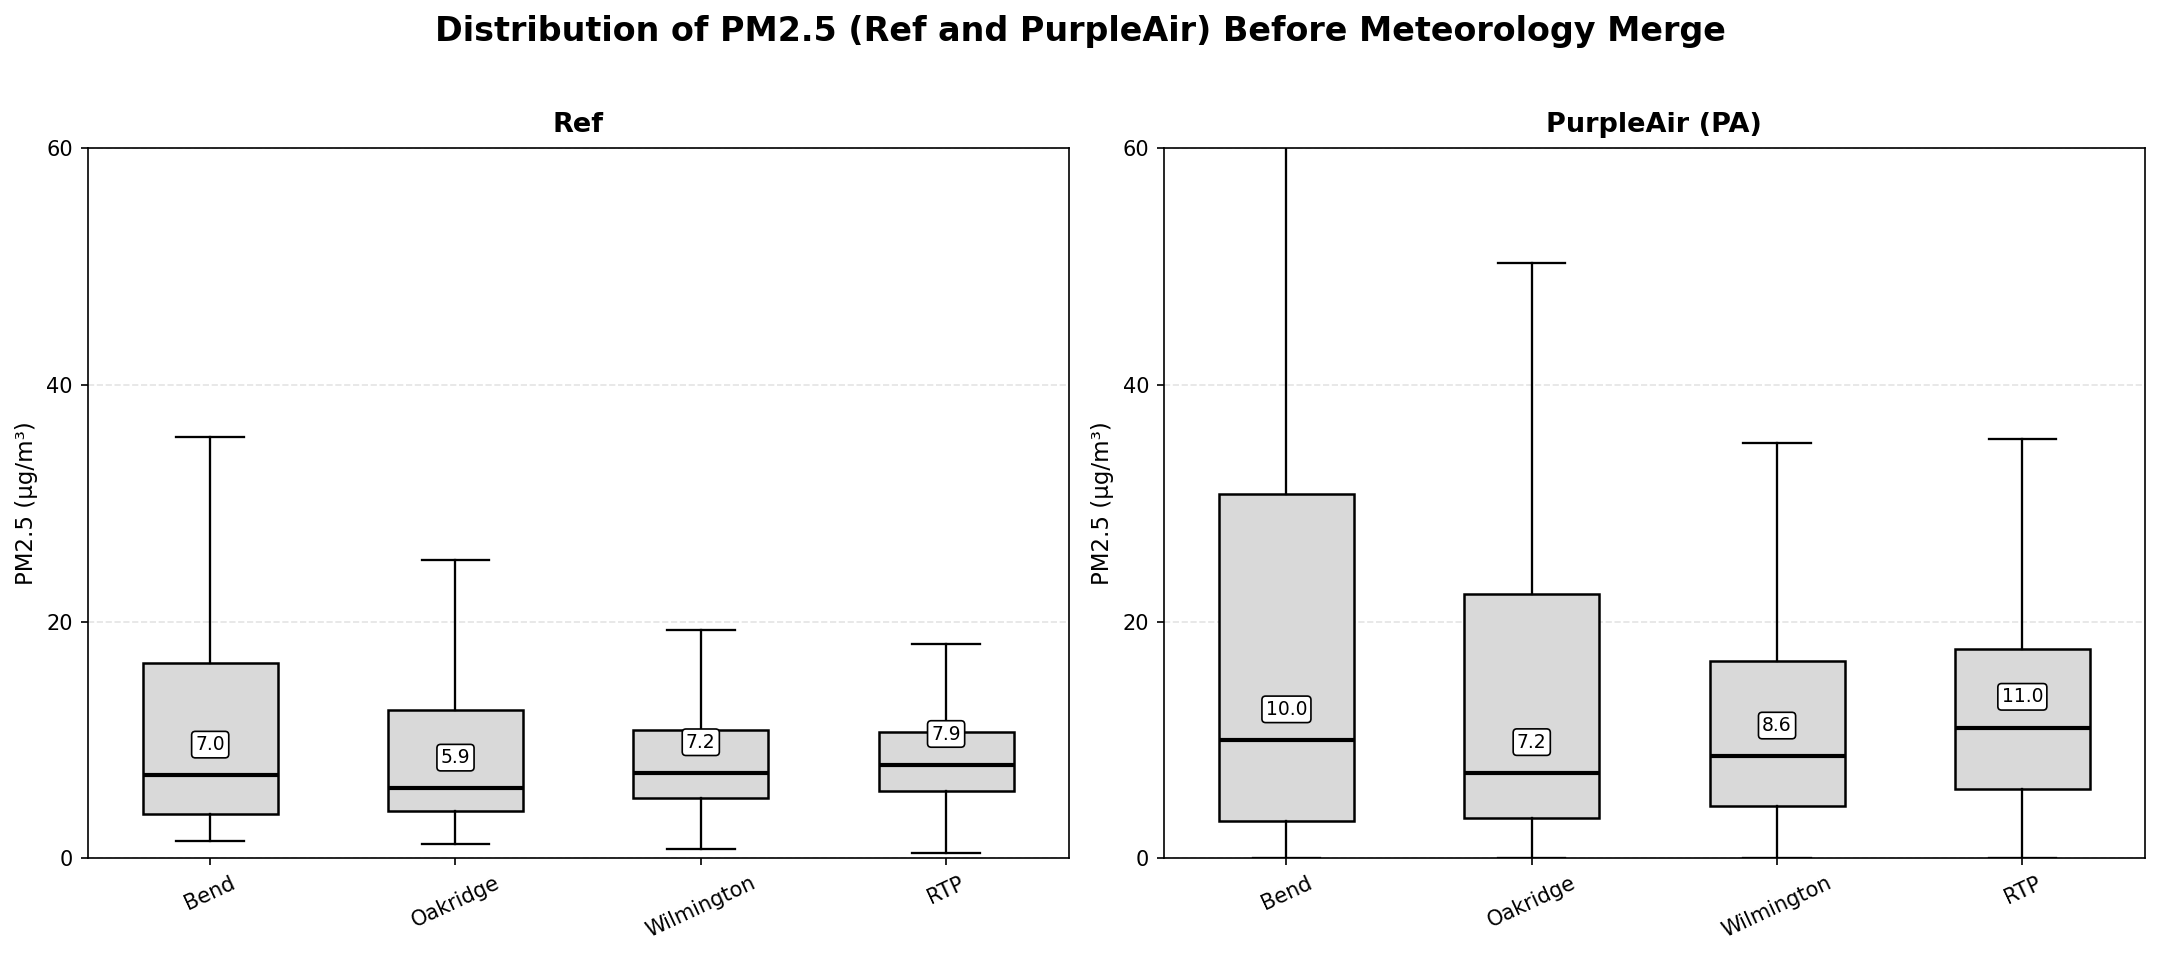

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Clean up duplicate columns (if any) ---
data = data.loc[:, ~data.columns.duplicated()].copy()

# --- Ensure correct column names exist ---
# (your df already has 'City', 'ref', 'PA' based on your earlier output)
required = ["City", "ref", "PA"]
missing = [c for c in required if c not in data.columns]
if missing:
    raise ValueError(f"Missing columns {missing}. Available: {data.columns.tolist()}")

# --- Combine RTP + RTP_S for plotting (prof wants RTP1+RTP2 together) ---
data_plot = data.copy()
data_plot["City"] = data_plot["City"].replace({"RTP_S": "RTP"})

# --- City order & pretty labels (removes _S in display) ---
city_order = ["Bend_S", "Oakridge_S", "Wilmington", "RTP"]
display_labels = ["Bend", "Oakridge", "Wilmington", "RTP"]

# --- Ensure numeric ---
data_plot["ref"] = pd.to_numeric(data_plot["ref"], errors="coerce")
data_plot["PA"]  = pd.to_numeric(data_plot["PA"], errors="coerce")

# --- Choose a clean y-axis cap (robust: 95th percentile across both panels) ---
all_vals = pd.concat([data_plot["ref"], data_plot["PA"]], ignore_index=True).dropna()
ymax = float(all_vals.quantile(0.95))
# round up to a nice number
if ymax <= 60:
    ymax = 60
elif ymax <= 100:
    ymax = 100
elif ymax <= 150:
    ymax = 150
else:
    ymax = 250

yticks = [0, ymax/3, 2*ymax/3, ymax]
yticks = [int(round(t)) for t in yticks]

def make_boxplot(ax, df, column, panel_title):
    values = [df[df["City"] == c][column].dropna().values for c in city_order]

    bp = ax.boxplot(
        values,
        labels=display_labels,
        patch_artist=True,
        showfliers=False,
        widths=0.55
    )

    # --- clean grayscale styling ---
    for box in bp["boxes"]:
        box.set_facecolor("#D9D9D9")
        box.set_edgecolor("black")
        box.set_linewidth(1.2)

    for whisker in bp["whiskers"]:
        whisker.set_color("black")
        whisker.set_linewidth(1.1)

    for cap in bp["caps"]:
        cap.set_color("black")
        cap.set_linewidth(1.1)

    for median in bp["medians"]:
        median.set_color("black")
        median.set_linewidth(2)

    # --- median labels (small offset scaled to ymax) ---
    offset = max(1.5, 0.03 * ymax)
    for i, vals in enumerate(values, start=1):
        if len(vals) > 0:
            med = float(np.median(vals))
            ax.text(
                i, med + offset,
                f"{med:.1f}",
                ha="center",
                va="bottom",
                fontsize=9,
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="black", linewidth=0.8)
            )

    ax.set_title(panel_title, fontsize=13, fontweight="bold", pad=8)
    ax.set_ylabel("PM2.5 (µg/m³)", fontsize=11)
    ax.set_ylim(0, ymax)
    ax.set_yticks(yticks)
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.tick_params(axis="x", rotation=25, labelsize=10)
    ax.tick_params(axis="y", labelsize=10)

# --- Build the final figure (clean + neat) ---
fig, axes = plt.subplots(1, 2, figsize=(14.5, 6.2), dpi=150)

make_boxplot(axes[0], data_plot, "ref", "Ref")
make_boxplot(axes[1], data_plot, "PA", "PurpleAir (PA)")

fig.suptitle(
    "Distribution of PM2.5 (Ref and PurpleAir) Before Meteorology Merge",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

# --- Optional: save for slides (high quality) ---
# fig.savefig("pm25_ref_pa_before_meteo.png", dpi=300, bbox_inches="tight")

In [44]:
data_fixed = data.copy()
data_fixed["City"] = data_fixed["City"].replace({"RTP_S": "RTP"})

data_fixed.groupby("City")["ref"].describe().round(2).reset_index()
desc = data_fixed.groupby("City")["ref"].describe().round(2).reset_index()
desc.index = desc.index + 1
desc

,City,count,mean,std,min,25%,50%,75%,max
1,Bend_S,15822.0,29.71,76.22,1.50,3.7,7.0,16.5,485.00
2,Oakridge_S,16785.0,36.44,92.16,1.20,4.0,5.9,12.5,717.10
3,RTP,20721.0,8.50,3.89,0.45,5.7,7.9,10.7,39.87
4,Wilmington,45640.0,8.45,4.91,0.80,5.1,7.2,10.8,34.70


/var/folders/hg/ltbkwjt559z64dywksz2sxv80000gn/T/ipykernel_50640/1284995111.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(vals, labels=city_order, patch_artist=True, showfliers=False)


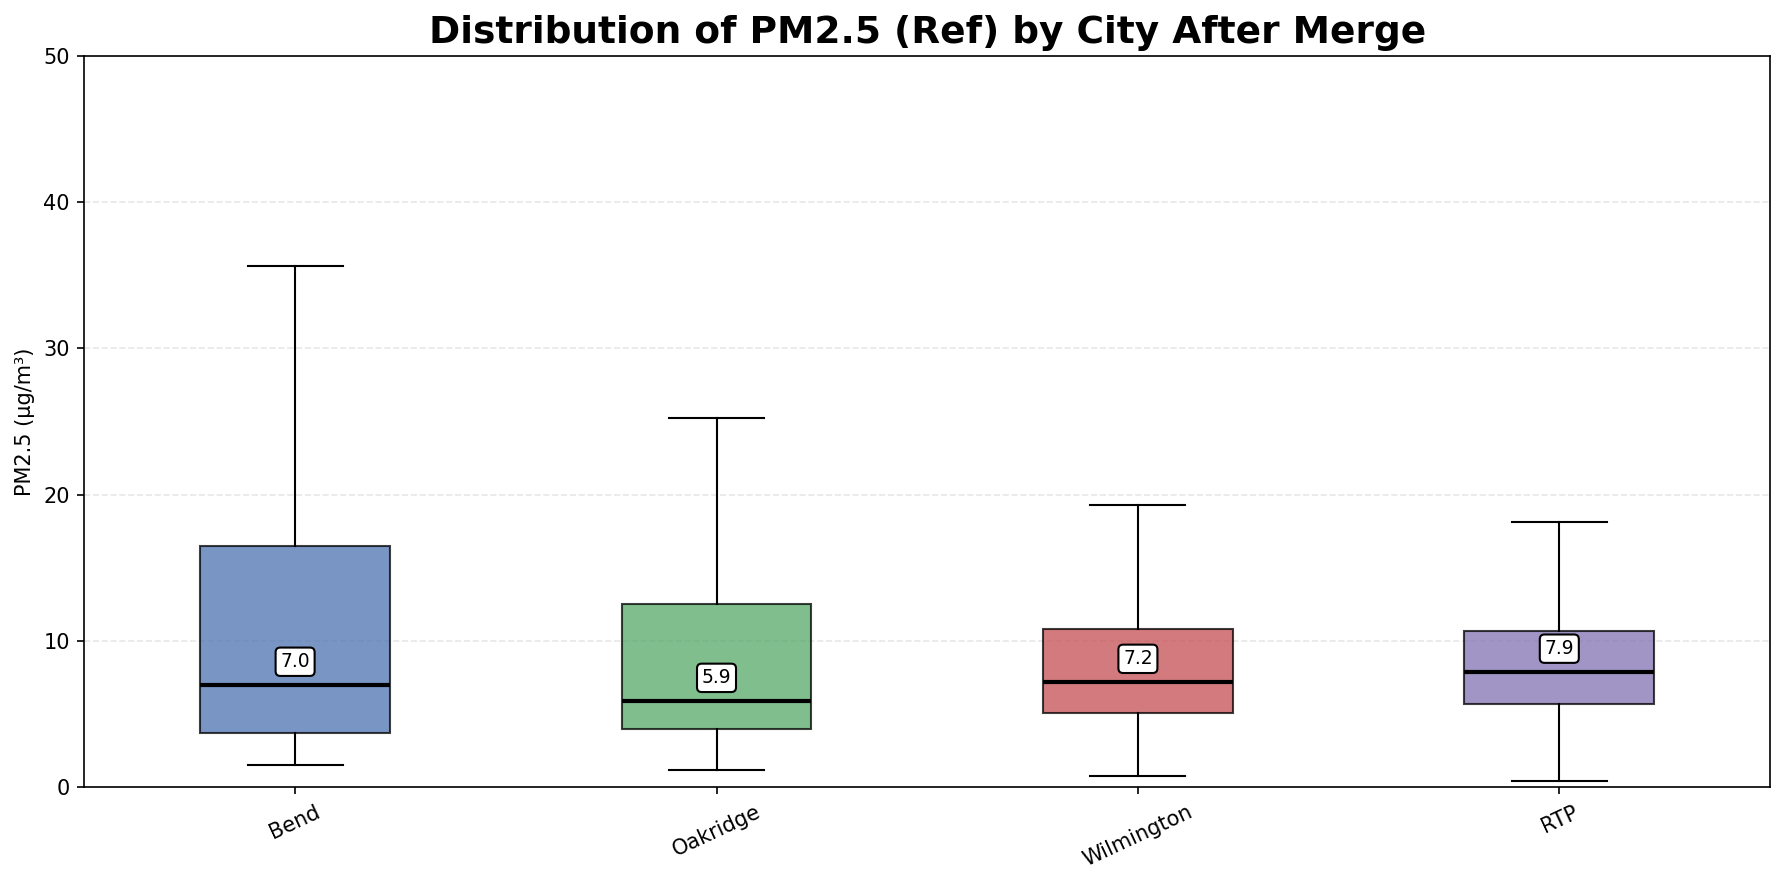

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- Load main cities ----
files = {
    "Bend": "cleaned_results/bend_pm_cleaned.csv",
    "Oakridge": "cleaned_results/oakridge_pm_cleaned.csv",
    "Wilmington": "cleaned_results/wilmington_pm_cleaned.csv"
}

dfs = []
for city, f in files.items():
    df = pd.read_csv(f)
    df["City"] = city
    dfs.append(df)

# ---- Combine RTP1 + RTP2 ----
rtp1 = pd.read_csv("cleaned_results/rtp1_pm_cleaned.csv")
rtp2 = pd.read_csv("cleaned_results/rtp2_pm_cleaned.csv")
rtp = pd.concat([rtp1, rtp2], ignore_index=True)
rtp["City"] = "RTP"

dfs.append(rtp)

data = pd.concat(dfs, ignore_index=True)
data["ref"] = pd.to_numeric(data["ref"], errors="coerce")

city_order = ["Bend", "Oakridge", "Wilmington", "RTP"]

vals = [data.loc[data["City"] == c, "ref"].dropna().values for c in city_order]

# 🎨 Soft academic color palette
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

plt.figure(figsize=(12, 6), dpi=150)
bp = plt.boxplot(vals, labels=city_order, patch_artist=True, showfliers=False)

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
    patch.set_edgecolor("black")

for median in bp["medians"]:
    median.set_color("black")
    median.set_linewidth(2)

for whisker in bp["whiskers"]:
    whisker.set_color("black")

for cap in bp["caps"]:
    cap.set_color("black")

# Median labels
for i, v in enumerate(vals, start=1):
    if len(v) > 0:
        med = np.median(v)
        plt.text(
            i,
            med + 1.2,
            f"{med:.1f}",
            ha="center",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.25",
                      facecolor="white",
                      edgecolor="black")
        )

plt.title("Distribution of PM2.5 (Ref) by City After Merge",
          fontsize=18, fontweight="bold")

plt.ylabel("PM2.5 (µg/m³)")
plt.xticks(rotation=25)

plt.ylim(0, 50)
plt.yticks([0, 10, 20, 30, 40, 50])

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

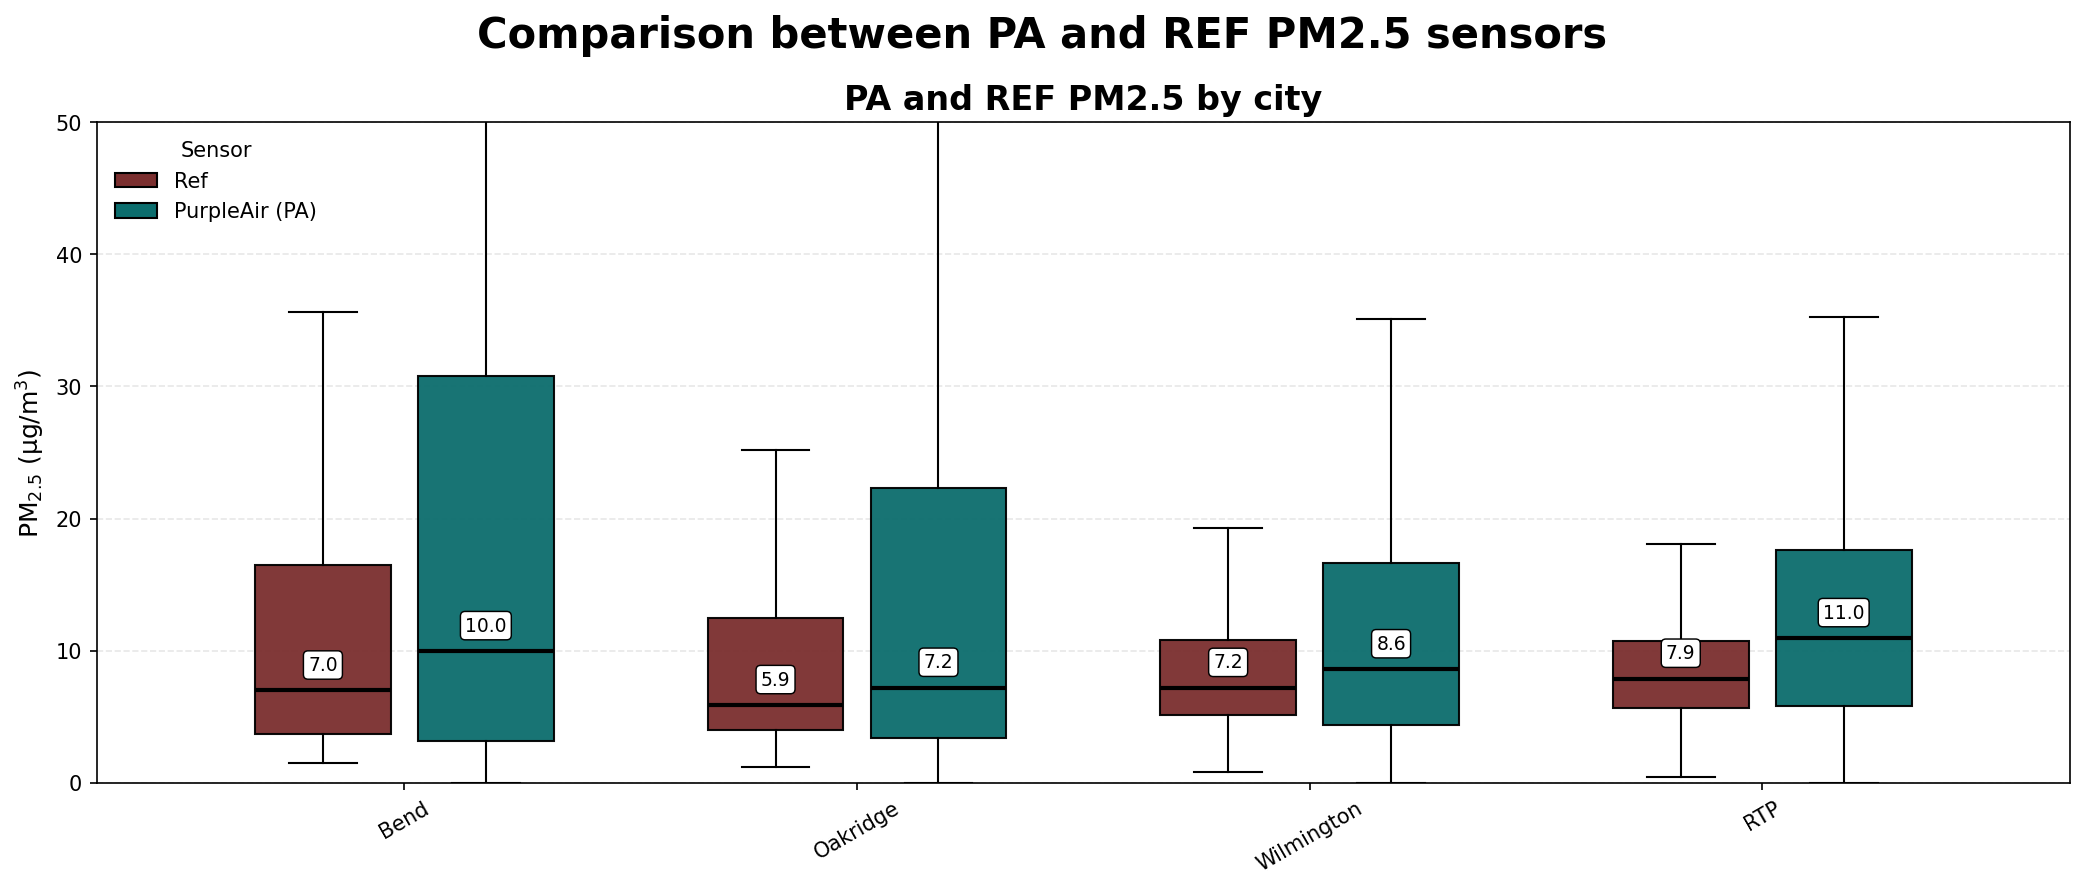

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ---- Load main cities ----
files = {
    "Bend": "cleaned_results/bend_pm_cleaned.csv",
    "Oakridge": "cleaned_results/oakridge_pm_cleaned.csv",
    "Wilmington": "cleaned_results/wilmington_pm_cleaned.csv",
}

dfs = []
for city, f in files.items():
    df = pd.read_csv(f)

    # normalize columns
    df.columns = df.columns.astype(str).str.strip().str.lower().str.replace(" ", "_").str.replace("-", "_")
    df = df.loc[:, ~df.columns.duplicated()].copy()  # ✅ remove duplicate column names

    df["City"] = city
    dfs.append(df)

# ---- Load RTP1 + RTP2 and combine ----
rtp1 = pd.read_csv("cleaned_results/rtp1_pm_cleaned.csv")
rtp2 = pd.read_csv("cleaned_results/rtp2_pm_cleaned.csv")

for d in (rtp1, rtp2):
    d.columns = d.columns.astype(str).str.strip().str.lower().str.replace(" ", "_").str.replace("-", "_")
    d.drop(columns=[c for c in d.columns if c.startswith("unnamed")], inplace=True, errors="ignore")
    d = d.loc[:, ~d.columns.duplicated()].copy()

rtp1 = rtp1.loc[:, ~rtp1.columns.duplicated()].copy()
rtp2 = rtp2.loc[:, ~rtp2.columns.duplicated()].copy()

rtp = pd.concat([rtp1, rtp2], ignore_index=True)
rtp["City"] = "RTP"
dfs.append(rtp)

# ---- Combine all ----
data = pd.concat(dfs, ignore_index=True)

# ✅ ensure required columns exist
if "ref" not in data.columns:
    raise ValueError(f"'ref' column not found. Columns: {data.columns.tolist()}")
if "pa" not in data.columns:
    raise ValueError(f"'pa' column not found. Columns: {data.columns.tolist()}")

# Numeric conversion
data["ref"] = pd.to_numeric(data["ref"], errors="coerce")
data["pa"]  = pd.to_numeric(data["pa"], errors="coerce")

city_order = ["Bend", "Oakridge", "Wilmington", "RTP"]

# Build arrays city-by-city (use ONLY City column)
ref_vals = [data.loc[data["City"] == c, "ref"].dropna().values for c in city_order]
pa_vals  = [data.loc[data["City"] == c, "pa"].dropna().values  for c in city_order]

# --- Plot positions (side-by-side per city) ---
x = np.arange(len(city_order)) + 1
offset = 0.18
pos_ref = x - offset
pos_pa  = x + offset
width = 0.30

fig, ax = plt.subplots(figsize=(14, 6), dpi=150)

bp_ref = ax.boxplot(ref_vals, positions=pos_ref, widths=width, patch_artist=True, showfliers=False)
bp_pa  = ax.boxplot(pa_vals,  positions=pos_pa,  widths=width, patch_artist=True, showfliers=False)

# --- Colors ---
ref_color = "#7A2E2E"   # dark red/brown
pa_color  = "#0B6D6D"   # teal

for b in bp_ref["boxes"]:
    b.set_facecolor(ref_color); b.set_edgecolor("black"); b.set_alpha(0.95)

for b in bp_pa["boxes"]:
    b.set_facecolor(pa_color); b.set_edgecolor("black"); b.set_alpha(0.95)

# Style lines
for key in ["whiskers", "caps", "medians"]:
    for line in bp_ref[key]:
        line.set_color("black")
        if key == "medians": line.set_linewidth(2)
    for line in bp_pa[key]:
        line.set_color("black")
        if key == "medians": line.set_linewidth(2)

# Median labels
def add_median_labels(vals_list, positions, y_pad=1.2):
    for vals, px in zip(vals_list, positions):
        if len(vals) == 0: 
            continue
        med = float(np.median(vals))
        ax.text(px, med + y_pad, f"{med:.1f}",
                ha="center", va="bottom", fontsize=9,
                bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="black", linewidth=0.7))

add_median_labels(ref_vals, pos_ref, y_pad=1.2)
add_median_labels(pa_vals,  pos_pa,  y_pad=1.2)

# Axis labels + ticks
ax.set_xticks(x)
ax.set_xticklabels(city_order, rotation=30)
ax.set_ylabel("PM$_{2.5}$ (µg/m$^3$)", fontsize=12)

ax.set_ylim(0, 50)
ax.set_yticks([0, 10, 20, 30, 40, 50])
ax.grid(axis="y", linestyle="--", alpha=0.3)

ax.set_title("PA and REF PM2.5 by city", fontsize=16, fontweight="bold")
fig.suptitle("Comparison between PA and REF PM2.5 sensors", fontsize=20, fontweight="bold", y=0.98)

legend_items = [
    Patch(facecolor=ref_color, edgecolor="black", label="Ref"),
    Patch(facecolor=pa_color, edgecolor="black", label="PurpleAir (PA)")
]
ax.legend(handles=legend_items, title="Sensor", loc="upper left", frameon=False)

plt.tight_layout()
plt.show()

In [9]:


files = {
    "Phoenix": "Phoenix_PM_weather_hourly_EDA_ready.csv",
    "Denver": "Denver_PM_weather_hourly_EDA_ready.csv",
    "Cedar Rapids": "Cedar_Rapids_PM_weather_hourly_EDA_ready.csv",
    "Decatur": "Decatur_PM_weather_hourly_EDA_ready.csv",
}

dfs = []
for city, path in files.items():
    df = pd.read_csv(path)

    # Make sure we have a consistent City column
    if "City" not in df.columns and "city" in df.columns:
        df = df.rename(columns={"city": "City"})
    if "City" not in df.columns:
        df["City"] = city  # fallback if the file doesn't contain City/city

    # Ensure City matches our key (optional but helps keep labels consistent)
    df["City"] = city

    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

# Make sure ref is numeric
data["ref"] = pd.to_numeric(data["ref"], errors="coerce")

# Confirm what columns you have
print("Columns:", list(data.columns))
print("Rows:", len(data))
data.head()

Columns: ['Unnamed :0', 'hr', 'City', 'id', 'RH', 'PA', 'ref', 'monitortype', 'State', 'week', 'adj', 'adjtype', 'wholdtype', 'temp_C', 'wind_speed', 'wind_dir']
Rows: 38855


,Unnamed :0,hr,City,id,RH,PA,ref,monitortype,State,week,adj,adjtype,wholdtype,temp_C,wind_speed,wind_dir
0,91166,2019-10-28 00:00,Phoenix,LTPP_AZ,24.400000,13.591167,10.7,Thermo Scientific TEOM 1405-DF Dichotomous FDM...,NaN,43.0,8.792417,C,LOBD,29.6,14.7,239
1,1151218,2019-10-28 01:00,Phoenix,LTPP_AZ,19.066667,4.006167,9.6,Thermo Scientific TEOM 1405-DF Dichotomous FDM...,LTPP_AZ,NaN,6.763960,E,LOSO,27.0,13.6,233
2,1151219,2019-10-28 02:00,Phoenix,LTPP_AZ,17.400000,2.200667,8.4,Thermo Scientific TEOM 1405-DF Dichotomous FDM...,LTPP_AZ,NaN,6.227052,E,LOSO,25.6,13.7,203
3,848081,2019-10-28 03:00,Phoenix,LTPP_AZ,18.933333,4.640333,6.6,Thermo Scientific TEOM 1405-DF Dichotomous FDM...,NaN,43.0,4.039619,F,LOBD,24.3,13.2,191
4,91202,2019-10-28 04:00,Phoenix,LTPP_AZ,20.400000,3.117667,3.5,Thermo Scientific TEOM 1405-DF Dichotomous FDM...,NaN,43.0,4.943964,C,LOBD,23.8,20.2,180


/var/folders/h5/jsk8sjbd1vxf6s8_7yppj8hm0000gn/T/ipykernel_18417/368355252.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


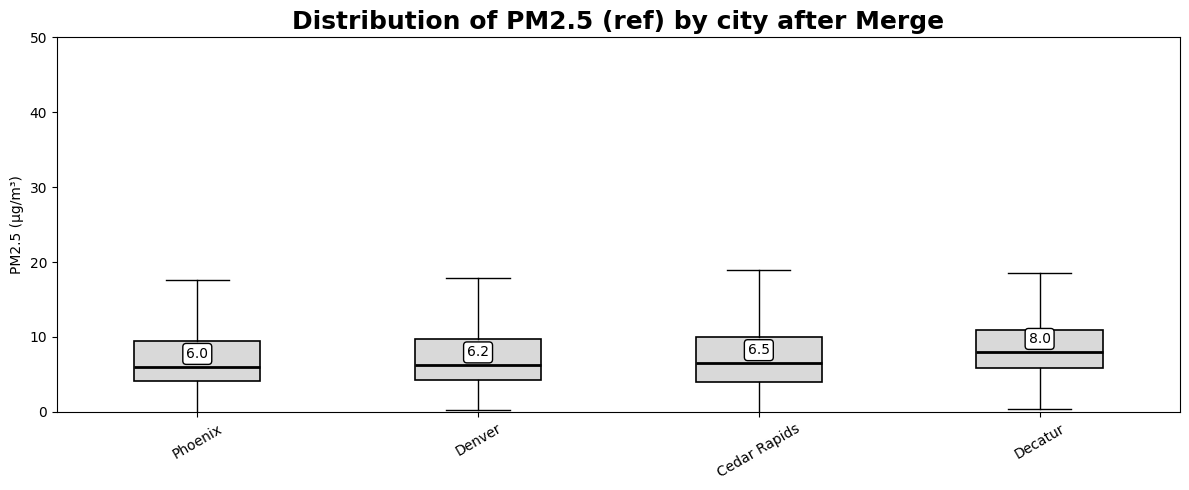

In [ ]:


city_order = ["Phoenix", "Denver", "Cedar Rapids", "Decatur"]

# Collect values (drop NA)
values = [data.loc[data["City"] == c, "ref"].dropna().values for c in city_order]

fig, ax = plt.subplots(figsize=(12, 5))

bp = ax.boxplot(
    values,
    labels=city_order,
    patch_artist=True,
    showfliers=False
)

# Gray styling
for box in bp["boxes"]:
    box.set_facecolor("#D9D9D9")
    box.set_edgecolor("black")
    box.set_linewidth(1.2)

for median in bp["medians"]:
    median.set_color("black")
    median.set_linewidth(2)

for whisker in bp["whiskers"]:
    whisker.set_color("black")
for cap in bp["caps"]:
    cap.set_color("black")

# Median labels (in little white boxes)
for i, vals in enumerate(values, start=1):
    if len(vals) > 0:
        med = float(np.median(vals))
        ax.text(
            i,
            med + 0.8,                 # small offset above the median line
            f"{med:.1f}",
            ha="center",
            va="bottom",
            fontsize=10,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="black")
        )

# Axis formatting to match what you asked
ax.set_ylim(0, 50)
ax.set_yticks([0, 10, 20, 30, 40, 50])
ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_title("Distribution of PM2.5 (ref) by city after Merge", fontsize=18, fontweight="bold")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

/var/folders/h5/jsk8sjbd1vxf6s8_7yppj8hm0000gn/T/ipykernel_18417/2525838050.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


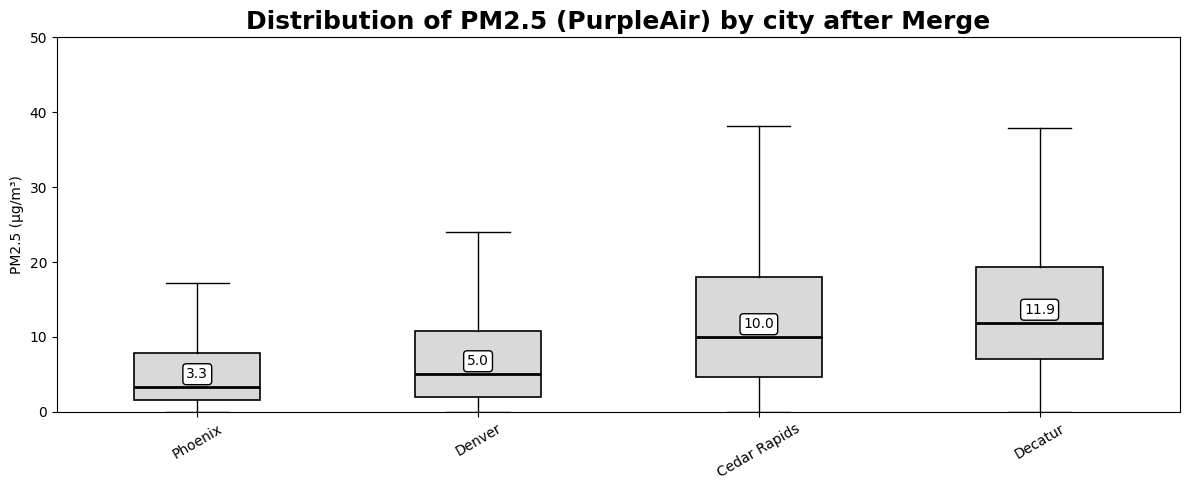

In [11]:
import numpy as np
import matplotlib.pyplot as plt

city_order = ["Phoenix", "Denver", "Cedar Rapids", "Decatur"]

# --- Detect PA column automatically ---
if "PA" in data.columns:
    pa_column = "PA"
elif "adj" in data.columns:
    pa_column = "adj"
else:
    raise ValueError("No PA column found (expected 'PA' or 'adj').")

# Ensure numeric
data[pa_column] = pd.to_numeric(data[pa_column], errors="coerce")

# Collect values by city
values = [
    data.loc[data["City"] == c, pa_column].dropna().values
    for c in city_order
]

# Create figure
fig, ax = plt.subplots(figsize=(12, 5))

bp = ax.boxplot(
    values,
    labels=city_order,
    patch_artist=True,
    showfliers=False
)

# Gray styling (same as ref plot)
for box in bp["boxes"]:
    box.set_facecolor("#D9D9D9")
    box.set_edgecolor("black")
    box.set_linewidth(1.2)

for median in bp["medians"]:
    median.set_color("black")
    median.set_linewidth(2)

for whisker in bp["whiskers"]:
    whisker.set_color("black")

for cap in bp["caps"]:
    cap.set_color("black")

# Add median labels
for i, vals in enumerate(values, start=1):
    if len(vals) > 0:
        med = float(np.median(vals))
        ax.text(
            i,
            med + 0.8,
            f"{med:.1f}",
            ha="center",
            va="bottom",
            fontsize=10,
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="white",
                edgecolor="black"
            )
        )

# Axis formatting
ax.set_ylim(0, 50)
ax.set_yticks([0, 10, 20, 30, 40, 50])
ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_title(
    "Distribution of PM2.5 (PurpleAir) by city after Merge",
    fontsize=18,
    fontweight="bold"
)
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

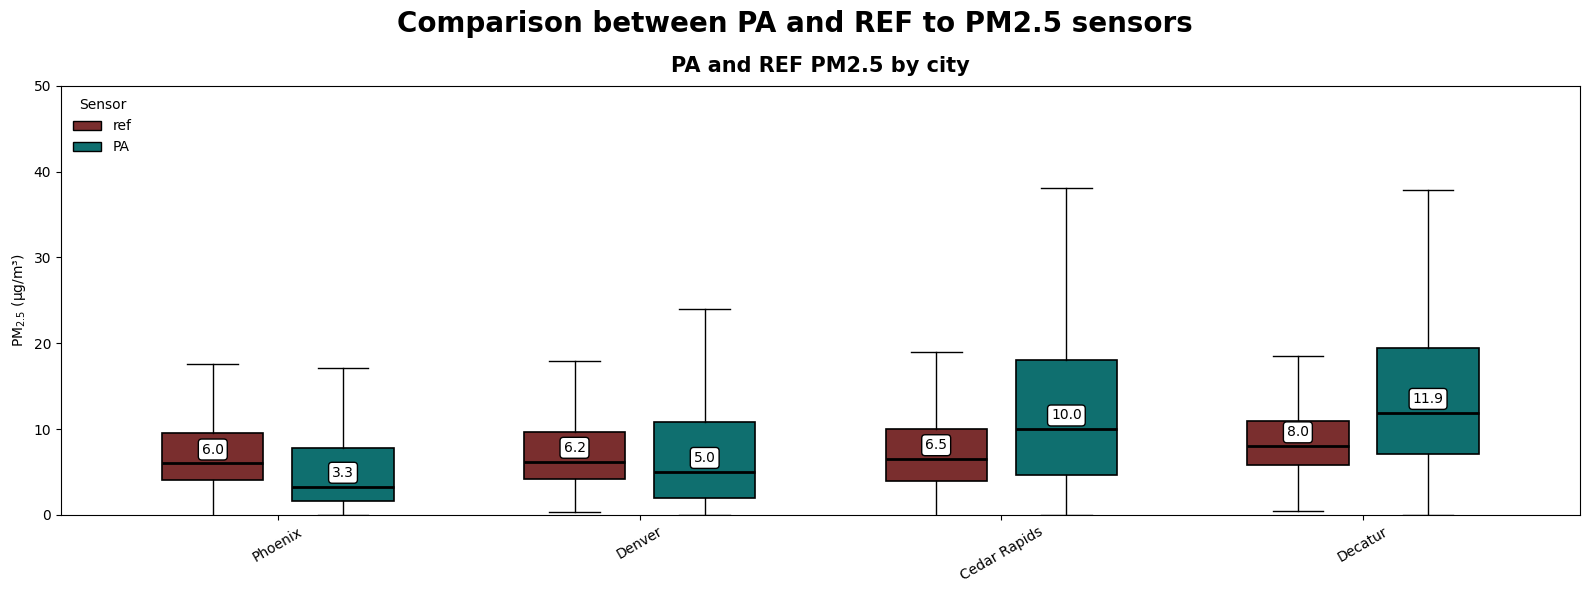

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


files = {
    "Phoenix": "Phoenix_PM_weather_hourly_EDA_ready.csv",
    "Denver": "Denver_PM_weather_hourly_EDA_ready.csv",
    "Cedar Rapids": "Cedar_Rapids_PM_weather_hourly_EDA_ready.csv",
    "Decatur": "Decatur_PM_weather_hourly_EDA_ready.csv",
}

dfs = []
for city, fp in files.items():
    df = pd.read_csv(fp)

    # ensure City column
    if "City" not in df.columns and "city" in df.columns:
        df = df.rename(columns={"city": "City"})
    df["City"] = city  # force consistent names/order

    # ensure ref numeric
    if "ref" in df.columns:
        df["ref"] = pd.to_numeric(df["ref"], errors="coerce")
    else:
        raise ValueError(f"'ref' column not found in {fp}")

    # detect PurpleAir column (PA or adj)
    if "PA" in df.columns:
        df["PA_val"] = pd.to_numeric(df["PA"], errors="coerce")
    elif "adj" in df.columns:
        df["PA_val"] = pd.to_numeric(df["adj"], errors="coerce")
    else:
        raise ValueError(f"No 'PA' or 'adj' column found in {fp}")

    dfs.append(df[["City", "ref", "PA_val"]])

data = pd.concat(dfs, ignore_index=True)

city_order = ["Phoenix", "Denver", "Cedar Rapids", "Decatur"]


ref_vals = [data.loc[data["City"] == c, "ref"].dropna().values for c in city_order]
pa_vals  = [data.loc[data["City"] == c, "PA_val"].dropna().values for c in city_order]

x = np.arange(len(city_order))
offset = 0.18
width = 0.28

fig, ax = plt.subplots(figsize=(16, 6))

bp_ref = ax.boxplot(
    ref_vals,
    positions=x - offset,
    widths=width,
    patch_artist=True,
    showfliers=False
)
bp_pa = ax.boxplot(
    pa_vals,
    positions=x + offset,
    widths=width,
    patch_artist=True,
    showfliers=False
)


ref_color = "#7A2E2E"   # maroon-ish
pa_color  = "#0F6F6F"   # teal-ish

def style_boxplot(bp, facecolor):
    for box in bp["boxes"]:
        box.set_facecolor(facecolor)
        box.set_edgecolor("black")
        box.set_linewidth(1.2)
    for median in bp["medians"]:
        median.set_color("black")
        median.set_linewidth(2)
    for whisker in bp["whiskers"]:
        whisker.set_color("black")
    for cap in bp["caps"]:
        cap.set_color("black")

style_boxplot(bp_ref, ref_color)
style_boxplot(bp_pa, pa_color)

# Median labels above each box
def add_median_labels(vals_list, positions):
    for vals, pos in zip(vals_list, positions):
        if len(vals) == 0:
            continue
        med = float(np.median(vals))
        ax.text(
            pos,
            med + 0.8,
            f"{med:.1f}",
            ha="center",
            va="bottom",
            fontsize=10,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="black")
        )

add_median_labels(ref_vals, x - offset)
add_median_labels(pa_vals,  x + offset)


ax.set_xlim(-0.6, len(city_order) - 0.4)
ax.set_xticks(x)
ax.set_xticklabels(city_order, rotation=30)
ax.set_ylabel("PM$_{2.5}$ (µg/m³)")

# Force y-range 0–50 as you requested
ax.set_ylim(0, 50)
ax.set_yticks([0, 10, 20, 30, 40, 50])

# Main title + subtitle like screenshot
fig.suptitle("Comparison between PA and REF to PM2.5 sensors", fontsize=20, fontweight="bold", y=0.98)
ax.set_title("PA and REF PM2.5 by city", fontsize=15, fontweight="bold", pad=10)

# Legend
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=ref_color, edgecolor="black", label="ref"),
    Patch(facecolor=pa_color, edgecolor="black", label="PA"),
]
ax.legend(handles=legend_handles, title="Sensor", loc="upper left", frameon=False)

plt.tight_layout()
plt.show()

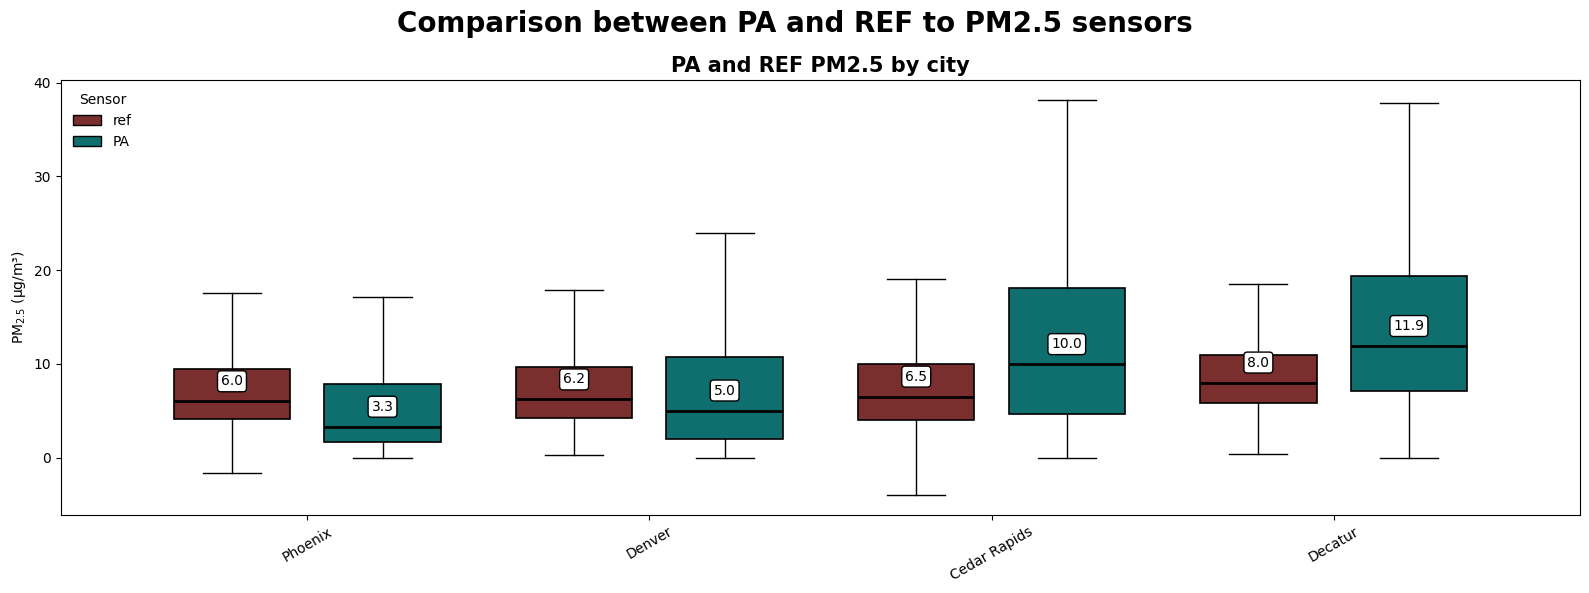

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


clean_files = {
    "Phoenix": "Phoenix_PM_weather_hourly_EDA_ready.csv",
    "Denver": "Denver_PM_weather_hourly_EDA_ready.csv",
    "Cedar Rapids": "Cedar_Rapids_PM_weather_hourly_EDA_ready.csv",
    "Decatur": "Decatur_PM_weather_hourly_EDA_ready.csv",
}

city_order = ["Phoenix", "Denver", "Cedar Rapids", "Decatur"]


Y_MAX = None  


dfs = []
for city, path in clean_files.items():
    df = pd.read_csv(path)

    # Standardize city column name
    if "City" not in df.columns and "city" in df.columns:
        df = df.rename(columns={"city": "City"})

    # Some files may have city value inconsistencies; force the correct label
    df["City"] = city

    
    if "PA" in df.columns:
        df["PA_val"] = df["PA"]
    elif "adj" in df.columns:
        df["PA_val"] = df["adj"]
    else:
        raise ValueError(f"{city}: Could not find PA column. Expected 'PA' or 'adj'.")

    # Ensure numeric
    df["ref"] = pd.to_numeric(df["ref"], errors="coerce")
    df["PA_val"] = pd.to_numeric(df["PA_val"], errors="coerce")

    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

# Keep only the cities we want (and keep order consistent)
data = data[data["City"].isin(city_order)].copy()


ref_vals = [data.loc[data["City"] == c, "ref"].dropna().values for c in city_order]
pa_vals  = [data.loc[data["City"] == c, "PA_val"].dropna().values for c in city_order]

x = np.arange(len(city_order))
offset = 0.22
width = 0.34  # SAME width for both groups

fig, ax = plt.subplots(figsize=(16, 6))

bp_ref = ax.boxplot(
    ref_vals,
    positions=x - offset,
    widths=width,
    patch_artist=True,
    showfliers=False
)

bp_pa = ax.boxplot(
    pa_vals,
    positions=x + offset,
    widths=width,
    patch_artist=True,
    showfliers=False
)

# Styling
ref_color = "#7A2E2E"
pa_color  = "#0F6F6F"

def style_boxplot(bp, facecolor):
    for box in bp["boxes"]:
        box.set_facecolor(facecolor)
        box.set_edgecolor("black")
        box.set_linewidth(1.2)
    for median in bp["medians"]:
        median.set_color("black")
        median.set_linewidth(2)
    for whisker in bp["whiskers"]:
        whisker.set_color("black")
        whisker.set_linewidth(1.0)
    for cap in bp["caps"]:
        cap.set_color("black")
        cap.set_linewidth(1.0)

style_boxplot(bp_ref, ref_color)
style_boxplot(bp_pa, pa_color)

# Optional y-limit (ONLY if you want 0–50)
if Y_MAX is not None:
    ax.set_ylim(0, Y_MAX)
    ax.set_yticks(list(range(0, Y_MAX + 1, 10)))

# Add median labels (after y-limits are set)
def add_median_labels(vals_list, positions):
    # Use a dynamic vertical offset so labels don’t overlap the box
    y0, y1 = ax.get_ylim()
    bump = 0.03 * (y1 - y0)

    for vals, pos in zip(vals_list, positions):
        if len(vals) == 0:
            continue
        med = float(np.median(vals))
        ax.text(
            pos,
            med + bump,
            f"{med:.1f}",
            ha="center",
            va="bottom",
            fontsize=10,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="black")
        )

add_median_labels(ref_vals, x - offset)
add_median_labels(pa_vals,  x + offset)

# Labels + titles (match your professor-style)
ax.set_xticks(x)
ax.set_xticklabels(city_order, rotation=30)
ax.set_ylabel("PM$_{2.5}$ (µg/m³)")

fig.suptitle("Comparison between PA and REF to PM2.5 sensors",
             fontsize=20, fontweight="bold")
ax.set_title("PA and REF PM2.5 by city",
             fontsize=15, fontweight="bold")

# Legend
legend_handles = [
    Patch(facecolor=ref_color, edgecolor="black", label="ref"),
    Patch(facecolor=pa_color,  edgecolor="black", label="PA"),
]
ax.legend(handles=legend_handles, title="Sensor", loc="upper left", frameon=False)

plt.tight_layout()
plt.show()

/var/folders/h5/jsk8sjbd1vxf6s8_7yppj8hm0000gn/T/ipykernel_18417/157367994.py:58: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/h5/jsk8sjbd1vxf6s8_7yppj8hm0000gn/T/ipykernel_18417/157367994.py:58: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


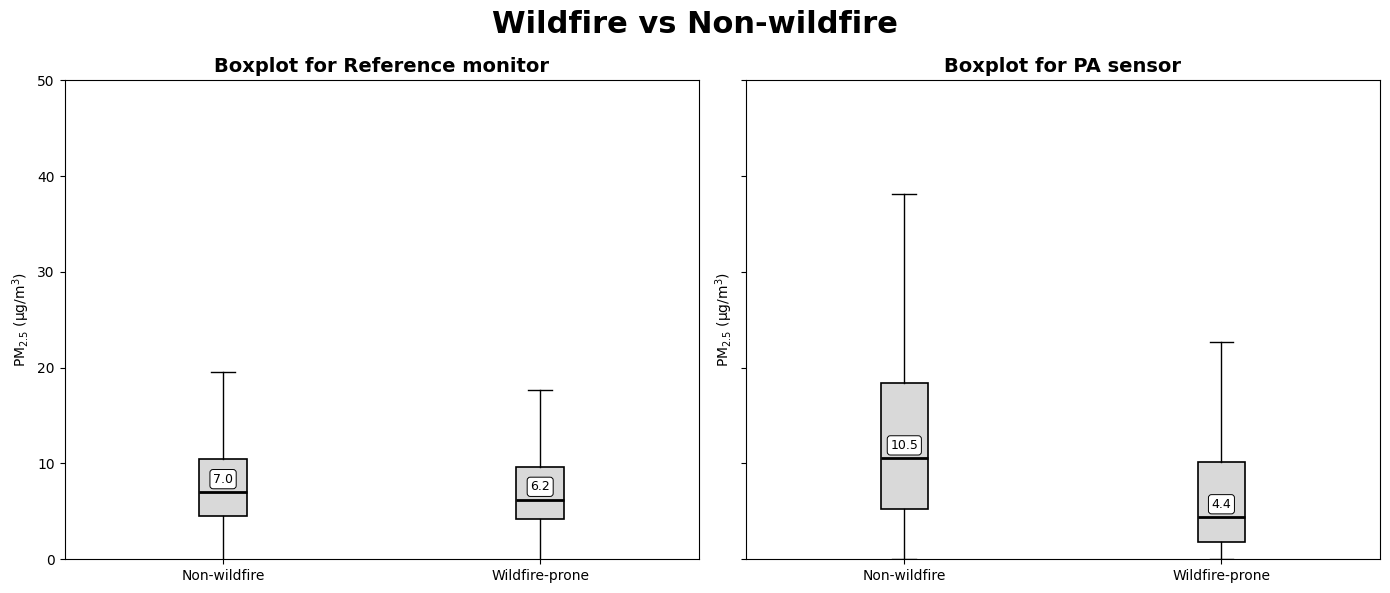


Median Comparison:
Reference → Non-wildfire: 7.0 | Wildfire-prone: 6.2
PurpleAir → Non-wildfire: 10.5 | Wildfire-prone: 4.4


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


base_dir = "."  # change if needed

files = {
    "Phoenix": "Phoenix_PM_weather_hourly_EDA_ready.csv",
    "Denver": "Denver_PM_weather_hourly_EDA_ready.csv",
    "Cedar Rapids": "Cedar_Rapids_PM_weather_hourly_EDA_ready.csv",
    "Decatur": "Decatur_PM_weather_hourly_EDA_ready.csv",
}

wildfire_cities = {"Phoenix", "Denver"}

dfs = []

for city, fname in files.items():
    df = pd.read_csv(os.path.join(base_dir, fname))

    df["City"] = city
    df["ref"] = pd.to_numeric(df["ref"], errors="coerce")
    df["PA"]  = pd.to_numeric(df["PA"], errors="coerce")

    dfs.append(df[["City", "ref", "PA"]])

data = pd.concat(dfs, ignore_index=True)

# Create wildfire grouping
data["Group"] = np.where(
    data["City"].isin(wildfire_cities),
    "Wildfire-prone",
    "Non-wildfire"
)

def grouped_vals(df, col):
    non = df.loc[df["Group"] == "Non-wildfire", col].dropna().values
    wf  = df.loc[df["Group"] == "Wildfire-prone", col].dropna().values
    return [non, wf]

def boxplot_panel(ax, vals, title):
    bp = ax.boxplot(
        vals,
        labels=["Non-wildfire", "Wildfire-prone"],
        patch_artist=True,
        showfliers=False
    )

    # Styling (match your earlier style)
    for box in bp["boxes"]:
        box.set_facecolor("#D9D9D9")
        box.set_edgecolor("black")
        box.set_linewidth(1.2)

    for med in bp["medians"]:
        med.set_color("black")
        med.set_linewidth(2)

    for w in bp["whiskers"]:
        w.set_color("black")
    for c in bp["caps"]:
        c.set_color("black")

    # Median labels
    meds = [np.median(v) if len(v) else np.nan for v in vals]
    for i, m in enumerate(meds, start=1):
        if np.isfinite(m):
            ax.text(
                i, m + 1,
                f"{m:.1f}",
                ha="center",
                fontsize=9,
                bbox=dict(
                    boxstyle="round,pad=0.25",
                    facecolor="white",
                    edgecolor="black",
                    linewidth=0.7
                )
            )

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_ylabel("PM$_{2.5}$ (µg/m$^3$)")

    # ---- Requested Y-axis range ----
    ax.set_ylim(0, 50)
    ax.set_yticks(np.arange(0, 51, 10))

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

boxplot_panel(
    axes[0],
    grouped_vals(data, "ref"),
    "Boxplot for Reference monitor"
)

boxplot_panel(
    axes[1],
    grouped_vals(data, "PA"),
    "Boxplot for PA sensor"
)

fig.suptitle("Wildfire vs Non-wildfire", fontsize=22, fontweight="bold")
plt.tight_layout()
plt.show()

ref_non, ref_wf = grouped_vals(data, "ref")
pa_non, pa_wf   = grouped_vals(data, "PA")

def safe_median(x):
    return float(np.median(x)) if len(x) else np.nan

print("\nMedian Comparison:")
print(f"Reference → Non-wildfire: {safe_median(ref_non):.1f} | Wildfire-prone: {safe_median(ref_wf):.1f}")
print(f"PurpleAir → Non-wildfire: {safe_median(pa_non):.1f} | Wildfire-prone: {safe_median(pa_wf):.1f}")

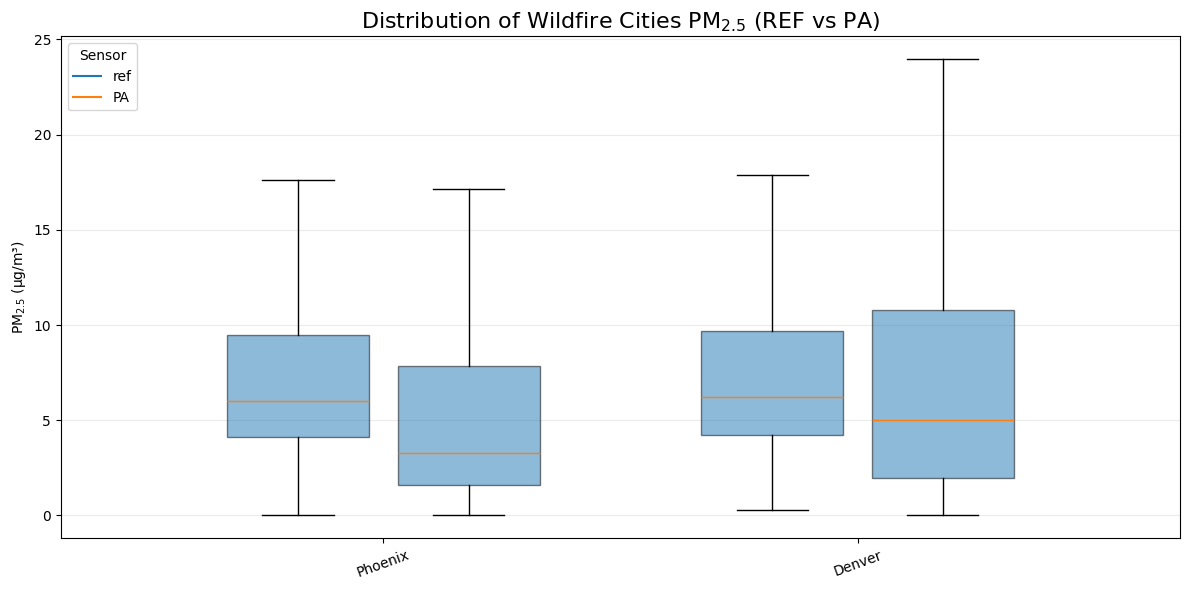

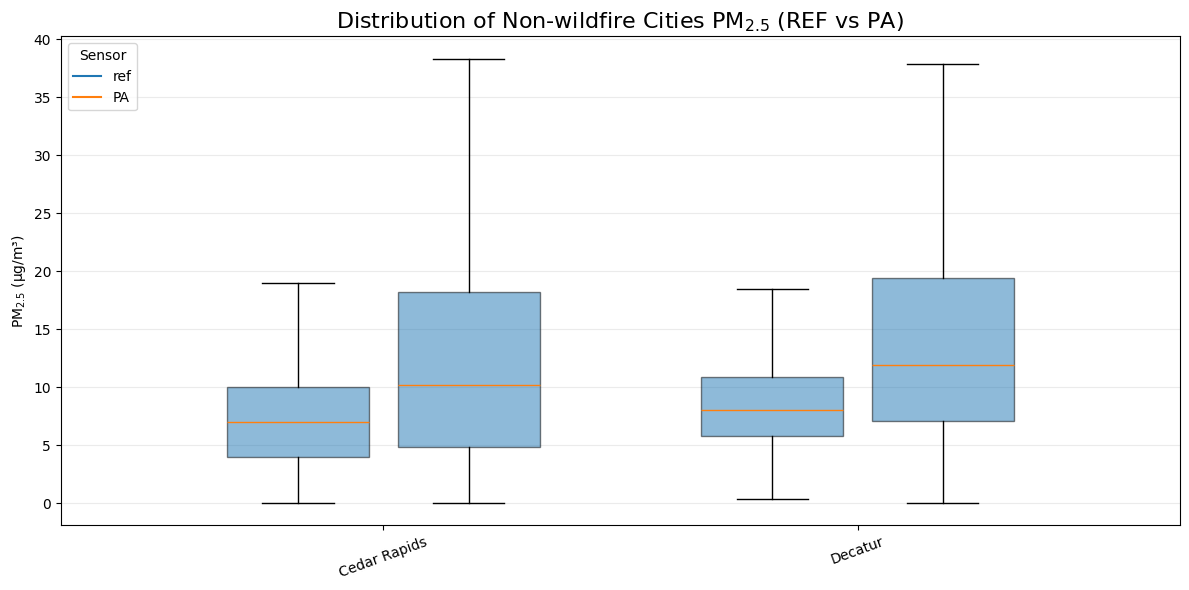

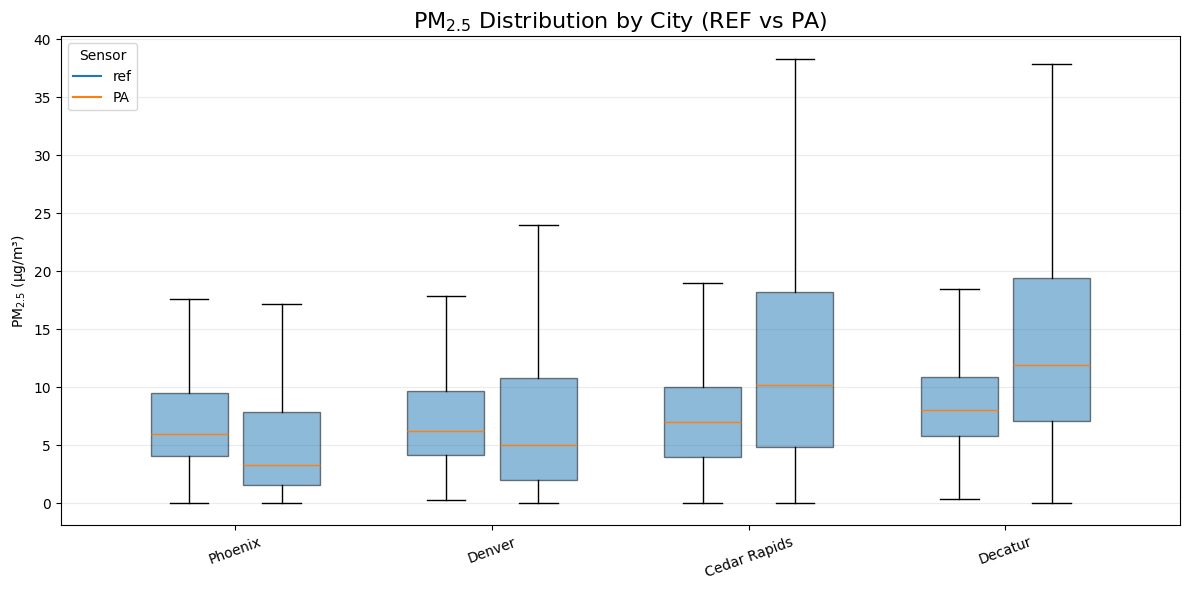

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- 1) Load + combine your 4 city files ----------
files = [
    "Phoenix_PM_weather_hourly_EDA_ready.csv",
    "Denver_PM_weather_hourly_EDA_ready.csv",
    "Cedar_Rapids_PM_weather_hourly_EDA_ready.csv",
    "Decatur_PM_weather_hourly_EDA_ready.csv",
]

dfs = [pd.read_csv(f) for f in files]
df = pd.concat(dfs, ignore_index=True)

# ---------- 2) Define wildfire vs non-wildfire groups (edit if your classification changes) ----------
wildfire_cities = {"Phoenix", "Denver"}
df["fire_group"] = np.where(df["city"].isin(wildfire_cities), "Wildfire", "Non-wildfire")

# ---------- 3) Clean PM2.5 columns (optional but recommended) ----------
# Keep only sensible values (adjust limits if you want)
for col in ["ref", "PA"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna(subset=["ref", "PA"])
df = df[(df["ref"] >= 0) & (df["PA"] >= 0)]

# ---------- 4) Helper: grouped boxplot (REF vs PA) for a set of cities ----------
def grouped_sensor_boxplot(data, cities, title, out_png):
    fig, ax = plt.subplots(figsize=(12, 6))

    positions_ref = []
    positions_pa = []
    data_ref = []
    data_pa = []

    for i, city in enumerate(cities, start=1):
        d = data[data["city"] == city]
        # REF box slightly left, PA slightly right
        positions_ref.append(i - 0.18)
        positions_pa.append(i + 0.18)
        data_ref.append(d["ref"].dropna().values)
        data_pa.append(d["PA"].dropna().values)

    bp_ref = ax.boxplot(
        data_ref, positions=positions_ref, widths=0.30, patch_artist=True, showfliers=False
    )
    bp_pa = ax.boxplot(
        data_pa, positions=positions_pa, widths=0.30, patch_artist=True, showfliers=False
    )

    # Simple colors (optional; remove if you want default look)
    for b in bp_ref["boxes"]:
        b.set_alpha(0.5)
    for b in bp_pa["boxes"]:
        b.set_alpha(0.5)

    ax.set_title(title, fontsize=16)
    ax.set_ylabel("PM$_{2.5}$ (µg/m³)")
    ax.set_xticks(range(1, len(cities) + 1))
    ax.set_xticklabels(cities, rotation=20)

    # Legend
    ax.plot([], [], label="ref")
    ax.plot([], [], label="PA")
    ax.legend(title="Sensor", loc="upper left")

    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.show()


# ---------- 5) Plot wildfire cities and non-wildfire cities separately ----------
wild_df = df[df["fire_group"] == "Wildfire"]
non_df  = df[df["fire_group"] == "Non-wildfire"]

wild_cities_order = ["Phoenix", "Denver"]
non_cities_order  = ["Cedar Rapids", "Decatur"]

grouped_sensor_boxplot(
    wild_df,
    wild_cities_order,
    "Distribution of Wildfire Cities PM$_{2.5}$ (REF vs PA)",
    "wildfire_cities_pm25_distribution.png",
)

grouped_sensor_boxplot(
    non_df,
    non_cities_order,
    "Distribution of Non-wildfire Cities PM$_{2.5}$ (REF vs PA)",
    "non_wildfire_cities_pm25_distribution.png",
)

# ---------- 6) (Optional) One combined figure for all 4 cities ----------
grouped_sensor_boxplot(
    df,
    ["Phoenix", "Denver", "Cedar Rapids", "Decatur"],
    "PM$_{2.5}$ Distribution by City (REF vs PA)",
    "all_cities_pm25_distribution.png",
)

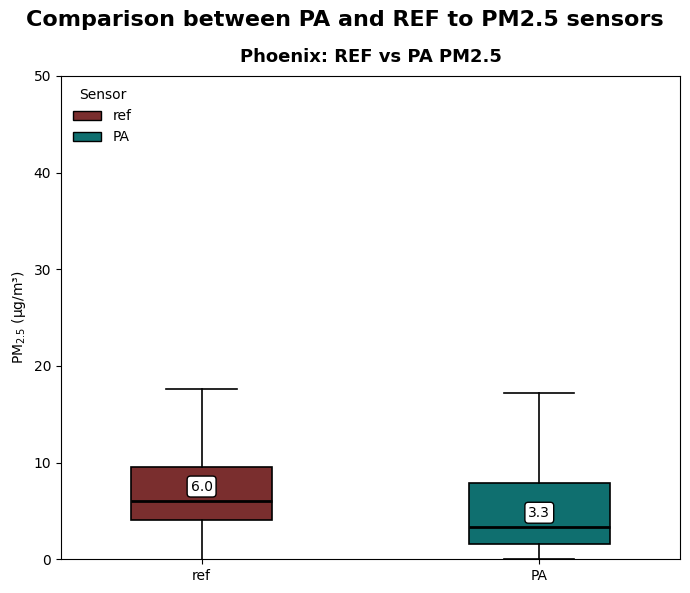

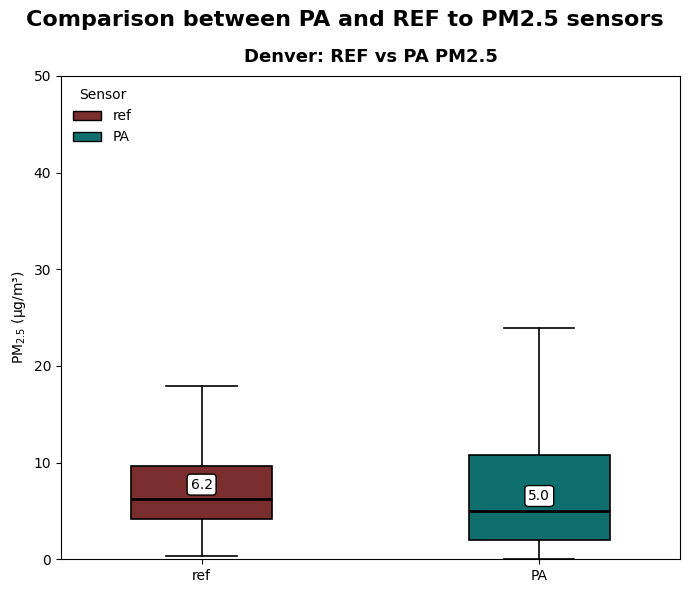

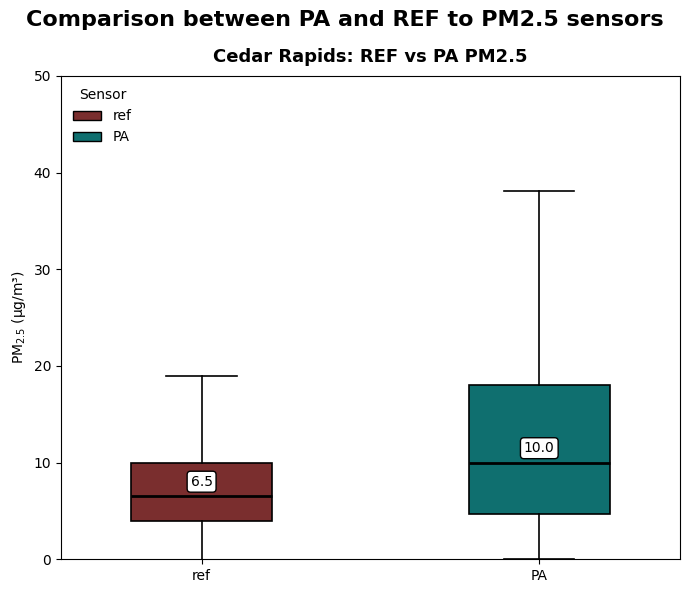

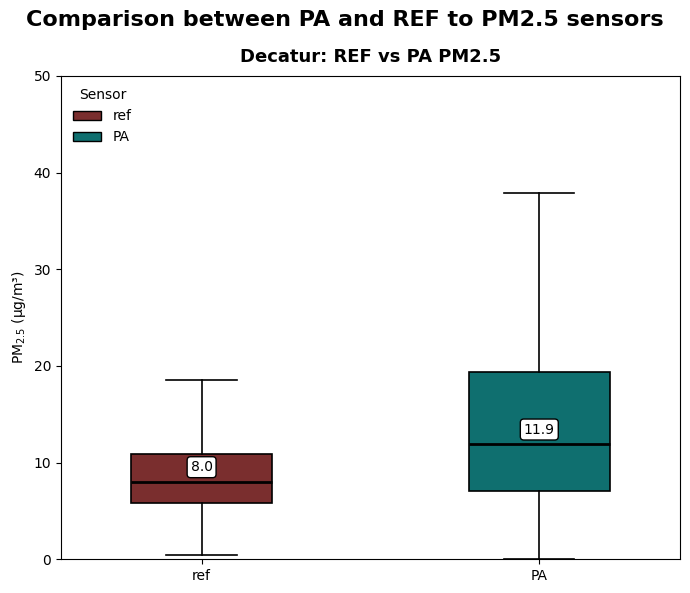

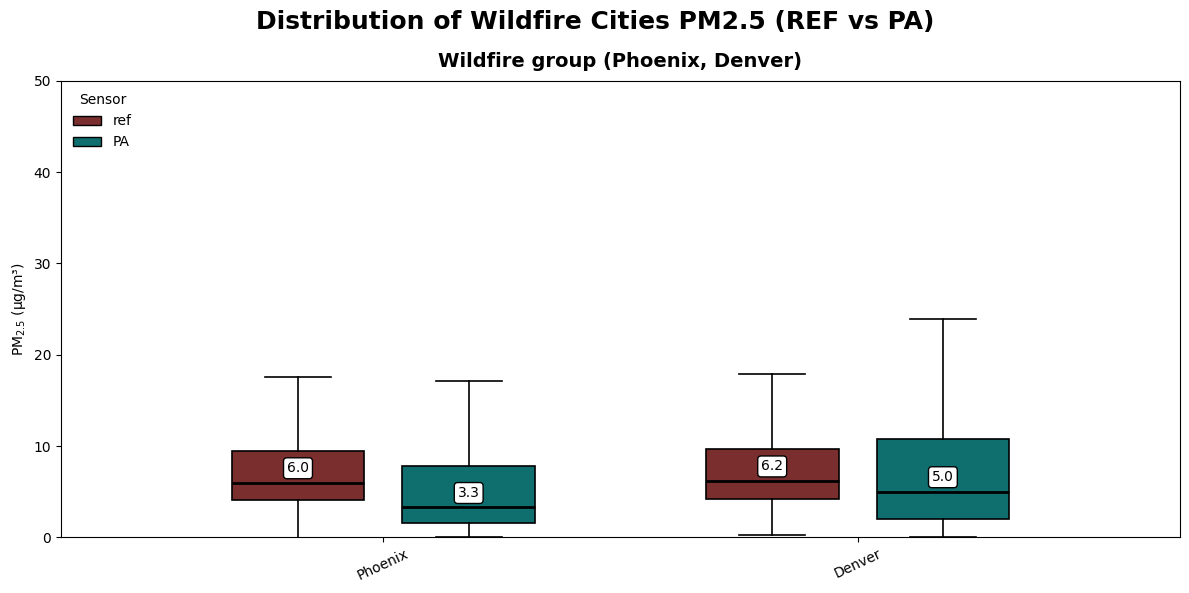

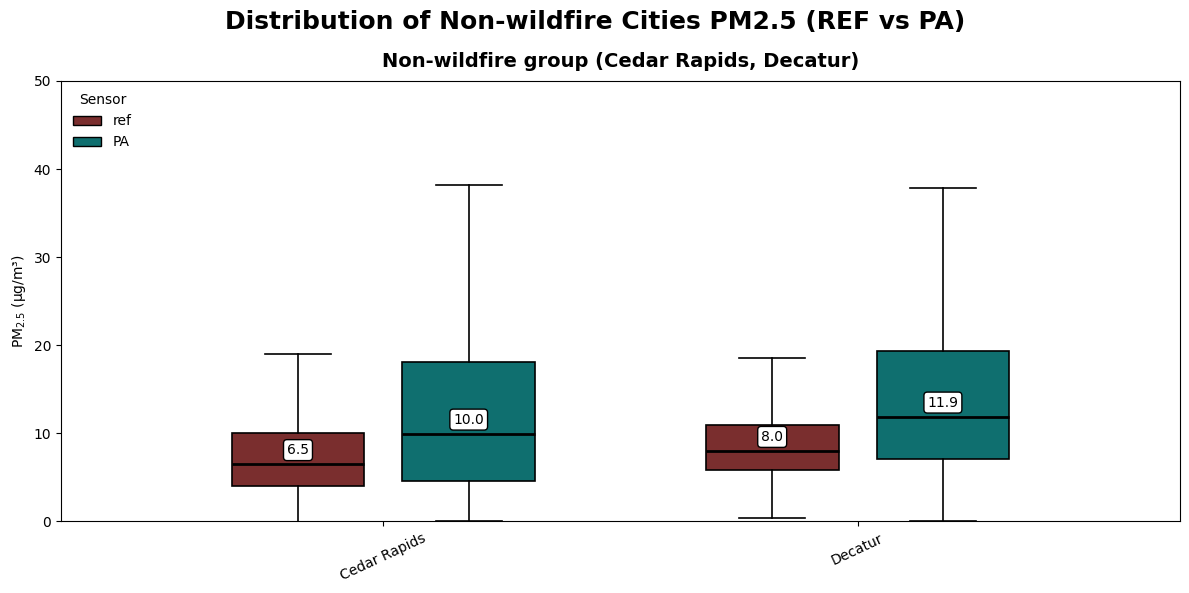

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# -----------------------------
# 1) Load + standardize data
# -----------------------------
files = {
    "Phoenix": "Phoenix_PM_weather_hourly_EDA_ready.csv",
    "Denver": "Denver_PM_weather_hourly_EDA_ready.csv",
    "Cedar Rapids": "Cedar_Rapids_PM_weather_hourly_EDA_ready.csv",
    "Decatur": "Decatur_PM_weather_hourly_EDA_ready.csv",
}

WILDFIRE = ["Phoenix", "Denver"]
NON_WILDFIRE = ["Cedar Rapids", "Decatur"]

dfs = []
for city, fp in files.items():
    df = pd.read_csv(fp)

    # force City name
    df["City"] = city

    # ensure ref numeric
    if "ref" not in df.columns:
        raise ValueError(f"'ref' column not found in {fp}")
    df["ref"] = pd.to_numeric(df["ref"], errors="coerce")

    # detect PA column (PA or adj)
    if "PA" in df.columns:
        df["PA_val"] = pd.to_numeric(df["PA"], errors="coerce")
    elif "adj" in df.columns:
        df["PA_val"] = pd.to_numeric(df["adj"], errors="coerce")
    else:
        raise ValueError(f"No 'PA' or 'adj' column found in {fp}")

    dfs.append(df[["City", "ref", "PA_val"]])

data = pd.concat(dfs, ignore_index=True)

# -----------------------------
# 2) Styling helpers
# -----------------------------
ref_color = "#7A2E2E"   # maroon
pa_color  = "#0F6F6F"   # teal

def style_boxplot(bp, facecolor):
    for box in bp["boxes"]:
        box.set_facecolor(facecolor)
        box.set_edgecolor("black")
        box.set_linewidth(1.2)
    for median in bp["medians"]:
        median.set_color("black")
        median.set_linewidth(2)
    for whisker in bp["whiskers"]:
        whisker.set_color("black")
        whisker.set_linewidth(1.2)
    for cap in bp["caps"]:
        cap.set_color("black")
        cap.set_linewidth(1.2)

def add_median_label(ax, vals, x_pos, y_pad=0.8):
    vals = np.array(vals)
    vals = vals[~np.isnan(vals)]
    if len(vals) == 0:
        return
    med = float(np.median(vals))
    ax.text(
        x_pos, med + y_pad, f"{med:.1f}",
        ha="center", va="bottom", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="black")
    )

legend_handles = [
    Patch(facecolor=ref_color, edgecolor="black", label="ref"),
    Patch(facecolor=pa_color, edgecolor="black", label="PA"),
]

# -----------------------------
# 3) Plot A: City-wise (one plot per city)
# -----------------------------
def plot_city_wise(data, city_list, ylim=(0, 50)):
    for city in city_list:
        ref_vals = data.loc[data["City"] == city, "ref"].dropna().values
        pa_vals  = data.loc[data["City"] == city, "PA_val"].dropna().values

        fig, ax = plt.subplots(figsize=(7, 6))

        bp_ref = ax.boxplot([ref_vals], positions=[0.9], widths=0.5,
                            patch_artist=True, showfliers=False)
        bp_pa  = ax.boxplot([pa_vals],  positions=[2.1], widths=0.5,
                            patch_artist=True, showfliers=False)

        style_boxplot(bp_ref, ref_color)
        style_boxplot(bp_pa, pa_color)

        add_median_label(ax, ref_vals, 0.9)
        add_median_label(ax, pa_vals,  2.1)

        ax.set_xticks([0.9, 2.1])
        ax.set_xticklabels(["ref", "PA"])
        ax.set_ylabel("PM$_{2.5}$ (µg/m³)")
        ax.set_ylim(*ylim)

        fig.suptitle("Comparison between PA and REF to PM2.5 sensors",
                     fontsize=16, fontweight="bold", y=0.98)
        ax.set_title(f"{city}: REF vs PA PM2.5", fontsize=13, fontweight="bold", pad=10)

        ax.legend(handles=legend_handles, title="Sensor", loc="upper left", frameon=False)
        plt.tight_layout()
        plt.show()

# -----------------------------
# 4) Plot B: Group comparison (wildfire vs non-wildfire separately)
#    - Same style as your "2nd picture" (paired boxes by city)
# -----------------------------
def plot_group_by_city(data, cities, title_main, title_sub, ylim=(0, 50)):
    city_order = cities

    ref_vals = [data.loc[data["City"] == c, "ref"].dropna().values for c in city_order]
    pa_vals  = [data.loc[data["City"] == c, "PA_val"].dropna().values for c in city_order]

    x = np.arange(len(city_order))
    offset = 0.18
    width = 0.28

    fig, ax = plt.subplots(figsize=(12, 6))

    bp_ref = ax.boxplot(ref_vals, positions=x - offset, widths=width,
                        patch_artist=True, showfliers=False)
    bp_pa  = ax.boxplot(pa_vals,  positions=x + offset, widths=width,
                        patch_artist=True, showfliers=False)

    style_boxplot(bp_ref, ref_color)
    style_boxplot(bp_pa, pa_color)

    # median labels
    for vals, pos in zip(ref_vals, x - offset):
        add_median_label(ax, vals, pos)
    for vals, pos in zip(pa_vals, x + offset):
        add_median_label(ax, vals, pos)

    ax.set_xticks(x)
    ax.set_xticklabels(city_order, rotation=25)
    ax.set_ylabel("PM$_{2.5}$ (µg/m³)")
    ax.set_ylim(*ylim)

    fig.suptitle(title_main, fontsize=18, fontweight="bold", y=0.98)
    ax.set_title(title_sub, fontsize=14, fontweight="bold", pad=10)

    ax.legend(handles=legend_handles, title="Sensor", loc="upper left", frameon=False)
    plt.tight_layout()
    plt.show()

# -----------------------------
# RUN THESE
# -----------------------------
# A) City-wise plots (4 separate figures)
plot_city_wise(data, ["Phoenix", "Denver", "Cedar Rapids", "Decatur"], ylim=(0, 50))

# B1) Wildfire cities only
plot_group_by_city(
    data,
    WILDFIRE,
    title_main="Distribution of Wildfire Cities PM2.5 (REF vs PA)",
    title_sub="Wildfire group (Phoenix, Denver)",
    ylim=(0, 50)
)

# B2) Non-wildfire cities only
plot_group_by_city(
    data,
    NON_WILDFIRE,
    title_main="Distribution of Non-wildfire Cities PM2.5 (REF vs PA)",
    title_sub="Non-wildfire group (Cedar Rapids, Decatur)",
    ylim=(0, 50)
)